# NeuralRetail – Data Cleaning & EDA

Notebook version with proper Jupyter cells and inline charts.

## STEP 1 – LOAD DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100

print("\n" + "="*60)
print("  STEP 1 – LOADING DATASET")
print("="*60)

df = pd.read_excel("online_retail_sample1.xlsx")

df = df.rename(columns={
    "Price"       : "UnitPrice",
    "Customer ID" : "CustomerID",
    "Invoice"     : "InvoiceNo"
})

# Strip whitespace from all column names
df.columns = df.columns.str.strip()

print(f"\n✅  Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"   Columns : {list(df.columns)}")



  STEP 1 – LOADING DATASET

✅  Dataset loaded successfully!
   Rows    : 1,048,575
   Columns : 8
   Columns : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## STEP 2 – DATA SUMMARY (before cleaning)

In [2]:


print("\n" + "="*60)
print("  STEP 2 – DATA SUMMARY (BEFORE CLEANING)")
print("="*60)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Last 5 Rows ---")
print(df.tail())

print("\n--- Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Basic Statistics (Numeric Columns) ---")
print(df.describe())

print("\n--- Missing Values Per Column ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %"    : missing_pct
})
print(missing_df[missing_df["Missing Count"] > 0])

print(f"\n--- Duplicate Rows ---")
dup_count = df.duplicated().sum()
print(f"   Total duplicates: {dup_count}")

print(f"\n--- Unique Values Per Column ---")
for col in df.columns:
    print(f"   {col}: {df[col].nunique()} unique values")






  STEP 2 – DATA SUMMARY (BEFORE CLEANING)

--- First 5 Rows ---
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2009-12-01 07:45:00       6.95     13085.0  United Kingdom  
1 2009-12-01 07:45:00       6.75     13085.0  United Kingdom  
2 2009-12-01 07:45:00       6.75     13085.0  United Kingdom  
3 2009-12-01 07:45:00       2.10     13085.0  United Kingdom  
4 2009-12-01 07:45:00       1.25     13085.0  United Kingdom  

--- Last 5 Rows ---
        InvoiceNo StockCode                        Description  Quantity  \
1048570    580501     23284

## STEP 3 – CHARTS BEFORE CLEANING


  STEP 3 – CHARTS BEFORE CLEANING

[Chart 1] Missing Values per Column


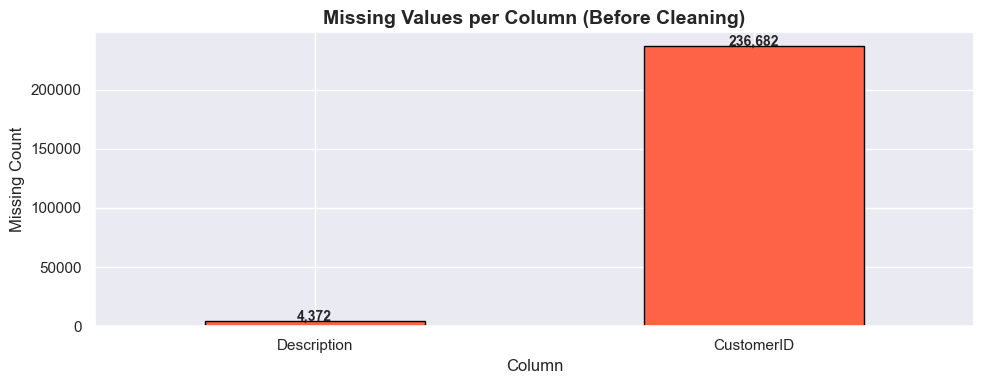

[Chart 2] Quantity Distribution (before cleaning)


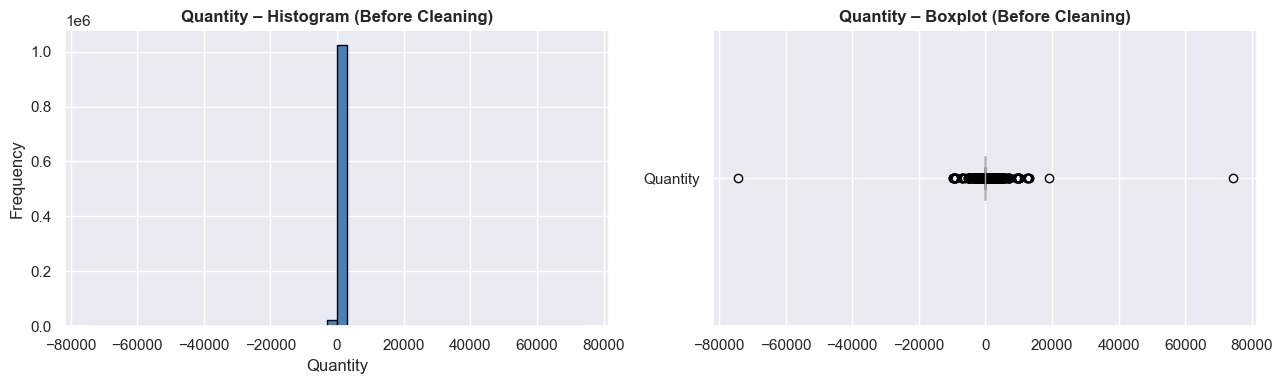

[Chart 3] UnitPrice Distribution (before cleaning)


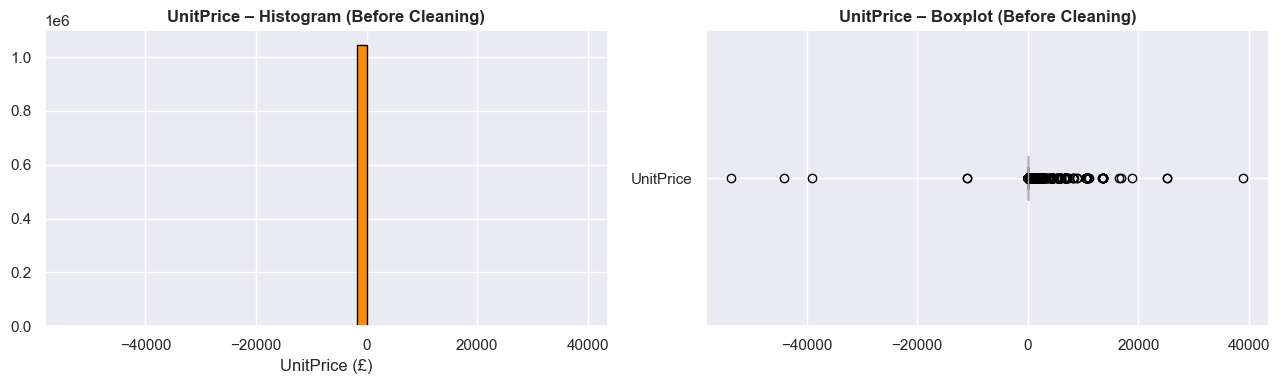

In [3]:
print("\n" + "="*60)
print("  STEP 3 – CHARTS BEFORE CLEANING")
print("="*60)

# Recalculate missing after rename so chart shows correct column names
missing = df.isnull().sum()

# --- Chart 1: Missing Values Bar Chart ---
print("\n[Chart 1] Missing Values per Column")
cols_with_missing = missing[missing > 0]
plt.figure(figsize=(10, 4))
cols_with_missing.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("Missing Values per Column (Before Cleaning)", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=0)
for i, v in enumerate(cols_with_missing):
    plt.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.show()

# --- Chart 2: Quantity Distribution ---
print("[Chart 2] Quantity Distribution (before cleaning)")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["Quantity"].dropna(), bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Quantity – Histogram (Before Cleaning)", fontweight="bold")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")
df.boxplot(column="Quantity", ax=axes[1], vert=False, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Quantity – Boxplot (Before Cleaning)", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Chart 3: UnitPrice Distribution ---
print("[Chart 3] UnitPrice Distribution (before cleaning)")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["UnitPrice"].dropna(), bins=50, color="darkorange", edgecolor="black")
axes[0].set_title("UnitPrice – Histogram (Before Cleaning)", fontweight="bold")
axes[0].set_xlabel("UnitPrice (£)")
df.boxplot(column="UnitPrice", ax=axes[1], vert=False, patch_artist=True,
           boxprops=dict(facecolor="darkorange", alpha=0.7))
axes[1].set_title("UnitPrice – Boxplot (Before Cleaning)", fontweight="bold")
plt.tight_layout()
plt.show()


## STEP 4 – HANDLE MISSING VALUES

In [4]:
print("\n" + "="*60)
print("  STEP 4 – HANDLING MISSING VALUES")
print("="*60)

print(f"\nBefore: {df.shape[0]:,} rows")

# CustomerID – drop rows (cannot do customer analysis without it)
before = len(df)
df = df.dropna(subset=["CustomerID"])
print(f"\n  [CustomerID]  Dropped {before - len(df):,} rows with missing CustomerID")

# ✅ FIX 2: Handle missing Description — was never handled before!
# 4,372 rows had no product description — fill with Unknown
desc_null = df["Description"].isnull().sum()
df["Description"] = df["Description"].fillna("Unknown")
print(f"  [Description] Filled {desc_null:,} missing values with 'Unknown'")

# UnitPrice – fill with median
median_price = df["UnitPrice"].median()
null_price   = df["UnitPrice"].isnull().sum()
df["UnitPrice"] = df["UnitPrice"].fillna(median_price)
print(f"  [UnitPrice]   Filled {null_price:,} missing with median = £{median_price:.2f}")

# Quantity – fill with median
median_qty = df["Quantity"].median()
null_qty   = df["Quantity"].isnull().sum()
df["Quantity"] = df["Quantity"].fillna(median_qty)
print(f"  [Quantity]    Filled {null_qty:,} missing with median = {median_qty:.0f}")

print(f"\n  Rows after handling missing: {df.shape[0]:,}")
print("\n--- Remaining Missing Values ---")
remaining = df.isnull().sum()
has_missing = remaining[remaining > 0]
if len(has_missing) == 0:
    print("  ✅  Zero missing values remaining!")
else:
    print(has_missing)



  STEP 4 – HANDLING MISSING VALUES

Before: 1,048,575 rows

  [CustomerID]  Dropped 236,682 rows with missing CustomerID
  [Description] Filled 0 missing values with 'Unknown'
  [UnitPrice]   Filled 0 missing with median = £1.95
  [Quantity]    Filled 0 missing with median = 5

  Rows after handling missing: 811,893

--- Remaining Missing Values ---
  ✅  Zero missing values remaining!


## STEP 5 – REMOVE DUPLICATES

In [5]:


print("\n" + "="*60)
print("  STEP 5 – REMOVING DUPLICATES")
print("="*60)

before = len(df)
df = df.drop_duplicates()
print(f"  Removed {before - len(df):,} duplicate rows")
print(f"  Rows after deduplication: {len(df):,}")






  STEP 5 – REMOVING DUPLICATES
  Removed 26,294 duplicate rows
  Rows after deduplication: 785,599


## STEP 6 – FIX DATA TYPES & BASIC VALIDATION

In [6]:


print("\n" + "="*60)
print("  STEP 6 – FIX DATA TYPES & VALIDATION")
print("="*60)

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("  ✅  InvoiceDate converted to datetime")

# CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)
print("  ✅  CustomerID converted to integer")

# Remove rows where Quantity or UnitPrice <= 0 (invalid transactions)
before = len(df)
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
print(f"  Removed {before - len(df):,} rows with zero/negative Quantity or Price")

# Remove cancelled orders (InvoiceNo starting with C)
before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"  Removed {before - len(df):,} cancelled orders (InvoiceNo starts with C)")

print(f"\n  Rows after validation: {len(df):,}")






  STEP 6 – FIX DATA TYPES & VALIDATION
  ✅  InvoiceDate converted to datetime
  ✅  CustomerID converted to integer
  Removed 18,230 rows with zero/negative Quantity or Price
  Removed 0 cancelled orders (InvoiceNo starts with C)

  Rows after validation: 767,369


## STEP 7 – OUTLIER DETECTION & REMOVAL (IQR METHOD)


  STEP 7 – OUTLIER DETECTION (IQR METHOD)

  Column: Quantity
    Q1        = 2.00
    Q3        = 12.00
    IQR       = 10.00
    Lower bound = -13.00
    Upper bound = 27.00
    Outlier count = 50,313 (6.6%)

  Column: UnitPrice
    Q1        = 1.25
    Q3        = 3.75
    IQR       = 2.50
    Lower bound = -2.50
    Upper bound = 7.50
    Outlier count = 64,667 (8.4%)

[Chart 4] IQR Outlier Detection


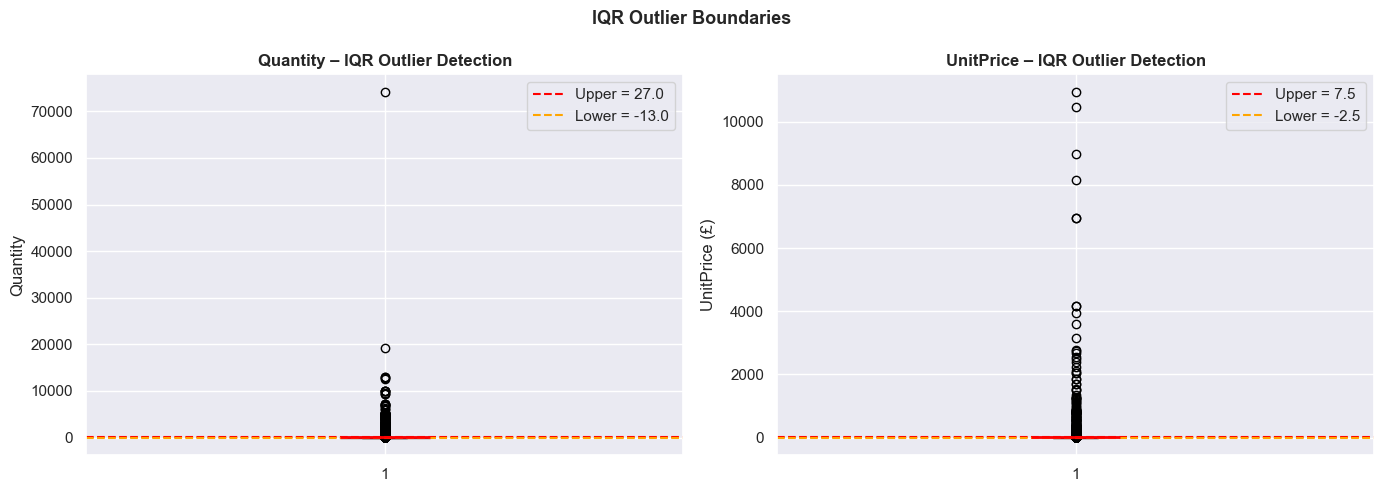


  Removed 114,458 outlier rows
  Rows after outlier removal: 652,911


In [7]:


print("\n" + "="*60)
print("  STEP 7 – OUTLIER DETECTION (IQR METHOD)")
print("="*60)

def detect_outliers_iqr(series, col_name):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"\n  Column: {col_name}")
    print(f"    Q1        = {Q1:.2f}")
    print(f"    Q3        = {Q3:.2f}")
    print(f"    IQR       = {IQR:.2f}")
    print(f"    Lower bound = {lower:.2f}")
    print(f"    Upper bound = {upper:.2f}")
    print(f"    Outlier count = {len(outliers):,} ({len(outliers)/len(series)*100:.1f}%)")
    return lower, upper

qty_low,   qty_high   = detect_outliers_iqr(df["Quantity"],  "Quantity")
price_low, price_high = detect_outliers_iqr(df["UnitPrice"], "UnitPrice")

# --- Chart 4: IQR Visualization ---
print("\n[Chart 4] IQR Outlier Detection")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity IQR
axes[0].boxplot(df["Quantity"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[0].axhline(qty_high, color="red", linestyle="--", linewidth=1.5, label=f"Upper = {qty_high:.1f}")
axes[0].axhline(qty_low,  color="orange", linestyle="--", linewidth=1.5, label=f"Lower = {qty_low:.1f}")
axes[0].set_title("Quantity – IQR Outlier Detection", fontweight="bold")
axes[0].set_ylabel("Quantity")
axes[0].legend()

# UnitPrice IQR
axes[1].boxplot(df["UnitPrice"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="darkorange", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].axhline(price_high, color="red", linestyle="--", linewidth=1.5, label=f"Upper = {price_high:.1f}")
axes[1].axhline(price_low,  color="orange", linestyle="--", linewidth=1.5, label=f"Lower = {price_low:.1f}")
axes[1].set_title("UnitPrice – IQR Outlier Detection", fontweight="bold")
axes[1].set_ylabel("UnitPrice (£)")
axes[1].legend()

plt.suptitle("IQR Outlier Boundaries", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Remove outliers
before = len(df)
df = df[
    (df["Quantity"]  >= qty_low)  & (df["Quantity"]  <= qty_high) &
    (df["UnitPrice"] >= price_low) & (df["UnitPrice"] <= price_high)
]
print(f"\n  Removed {before - len(df):,} outlier rows")
print(f"  Rows after outlier removal: {len(df):,}")





## STEP 8 – ADD EXTRA COLUMNS (Mentor Requirements)

In [8]:


print("\n" + "="*60)
print("  STEP 8 – ADDING EXTRA COLUMNS")
print("="*60)

# Revenue column
df["Revenue"] = (df["Quantity"] * df["UnitPrice"]).round(2)
print("  ✅  Added: Revenue = Quantity × UnitPrice")

# Date parts
df["Year"]      = df["InvoiceDate"].dt.year
df["Month"]     = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["IsWeekend"] = df["InvoiceDate"].dt.dayofweek.isin([5, 6]).astype(int)
print("  ✅  Added: Year, Month, DayOfWeek, IsWeekend")

# --- Weather data ---
rng = np.random.default_rng(99)
unique_dates = df["InvoiceDate"].dt.date.unique()
weather_df = pd.DataFrame({"Date": pd.to_datetime(unique_dates)})
doy = weather_df["Date"].dt.dayofyear
weather_df["AvgTempC"]   = (10 + 8 * np.sin((doy - 80) * 2 * np.pi / 365)
                             + rng.normal(0, 1.5, len(weather_df))).round(1)
weather_df["RainfallMM"] = rng.exponential(2.5, len(weather_df)).round(1)
weather_df["IsRainy"]    = (weather_df["RainfallMM"] > 3).astype(int)
weather_df["Date"]       = weather_df["Date"].dt.date
df["Date_key"]           = df["InvoiceDate"].dt.date
df = df.merge(weather_df, left_on="Date_key", right_on="Date", how="left")
df = df.drop(columns=["Date", "Date_key"])
print("  ✅  Added: AvgTempC, RainfallMM, IsRainy  (Weather)")

# --- Competitor price ---
sku_price = df.groupby("StockCode")["UnitPrice"].median().reset_index()
sku_price.columns = ["StockCode", "MedianPrice"]
sku_price["CompetitorPrice"] = (sku_price["MedianPrice"]
                                * rng.uniform(0.85, 1.15, len(sku_price))).round(2)
df = df.merge(sku_price[["StockCode","CompetitorPrice"]], on="StockCode", how="left")
df["PriceDiff_Pct"] = ((df["UnitPrice"] - df["CompetitorPrice"])
                        / df["CompetitorPrice"] * 100).round(2)
print("  ✅  Added: CompetitorPrice, PriceDiff_Pct")

# --- Customer demographics ---
customer_ids = df["CustomerID"].unique()
age_rng = np.random.default_rng(7)
regions    = ["North West","South East","London","Yorkshire","West Midlands",
              "East of England","South West","Scotland","Wales","North East"]
age_groups = ["18-24","25-34","35-44","45-54","55-64","65+"]
demo_df = pd.DataFrame({
    "CustomerID":  customer_ids,
    "Age":         age_rng.integers(18, 75, len(customer_ids)),
    "AgeGroup":    age_rng.choice(age_groups, len(customer_ids)),
    "Region":      age_rng.choice(regions,    len(customer_ids)),
    "Gender":      age_rng.choice(["M","F","Other"], len(customer_ids), p=[0.45,0.45,0.10]),
    "LoyaltyTier": age_rng.choice(["Bronze","Silver","Gold","Platinum"],
                                   len(customer_ids), p=[0.40,0.30,0.20,0.10]),
})
df = df.merge(demo_df, on="CustomerID", how="left")
print("  ✅  Added: Age, AgeGroup, Region, Gender, LoyaltyTier  (Demographics)")






  STEP 8 – ADDING EXTRA COLUMNS
  ✅  Added: Revenue = Quantity × UnitPrice
  ✅  Added: Year, Month, DayOfWeek, IsWeekend
  ✅  Added: AvgTempC, RainfallMM, IsRainy  (Weather)
  ✅  Added: CompetitorPrice, PriceDiff_Pct
  ✅  Added: Age, AgeGroup, Region, Gender, LoyaltyTier  (Demographics)


## STEP 9 – DATA SUMMARY (after cleaning)

In [9]:


print("\n" + "="*60)
print("  STEP 9 – DATA SUMMARY (AFTER CLEANING)")
print("="*60)

print(f"\n  Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n--- Cleaned Data – First 5 Rows ---")
print(df.head())
print("\n--- Statistics After Cleaning ---")
print(df[["Quantity","UnitPrice","Revenue","AvgTempC","CompetitorPrice"]].describe().round(2))
print("\n--- Missing Values After Cleaning ---")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "  ✅  Zero missing values!")






  STEP 9 – DATA SUMMARY (AFTER CLEANING)

  Final shape: 652,911 rows × 23 columns

--- Cleaned Data – First 5 Rows ---
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
4    489434     22064           PINK DOUGHNUT TRINKET POT         24   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  Year  \
0 2009-12-01 07:45:00       6.95       13085  United Kingdom     83.4  2009   
1 2009-12-01 07:45:00       6.75       13085  United Kingdom     81.0  2009   
2 2009-12-01 07:45:00       6.75       13085  United Kingdom     81.0  2009   
3 2009-12-01 07:45:00       1.25       13085  United Kingdom     30.0  2009   
4 2009-12-01 07:45:00       1.65       13085  Unite

## STEP 10 – EDA CHARTS (after cleaning)


  STEP 10 – EDA CHARTS (AFTER CLEANING)

[Chart 5] Correlation Heatmap


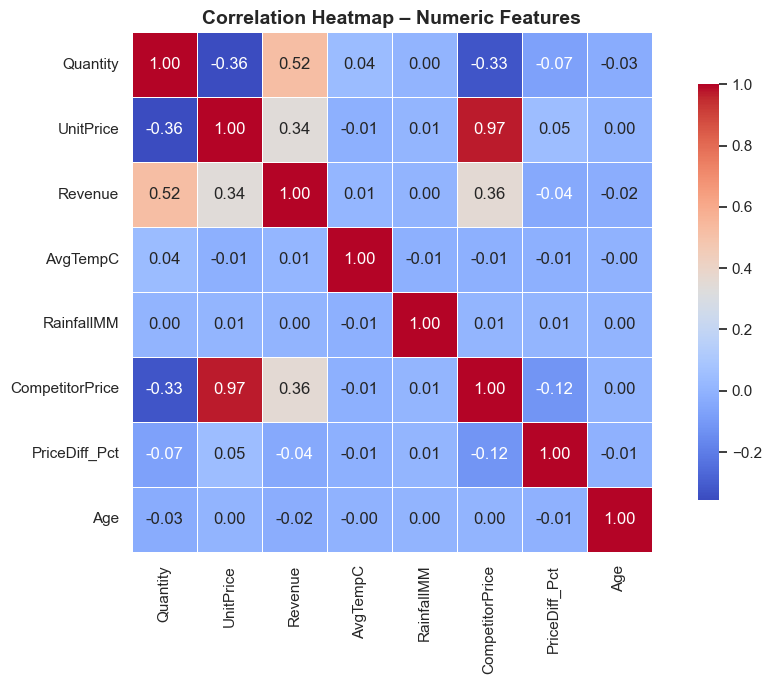

[Chart 6] Monthly Revenue Trend


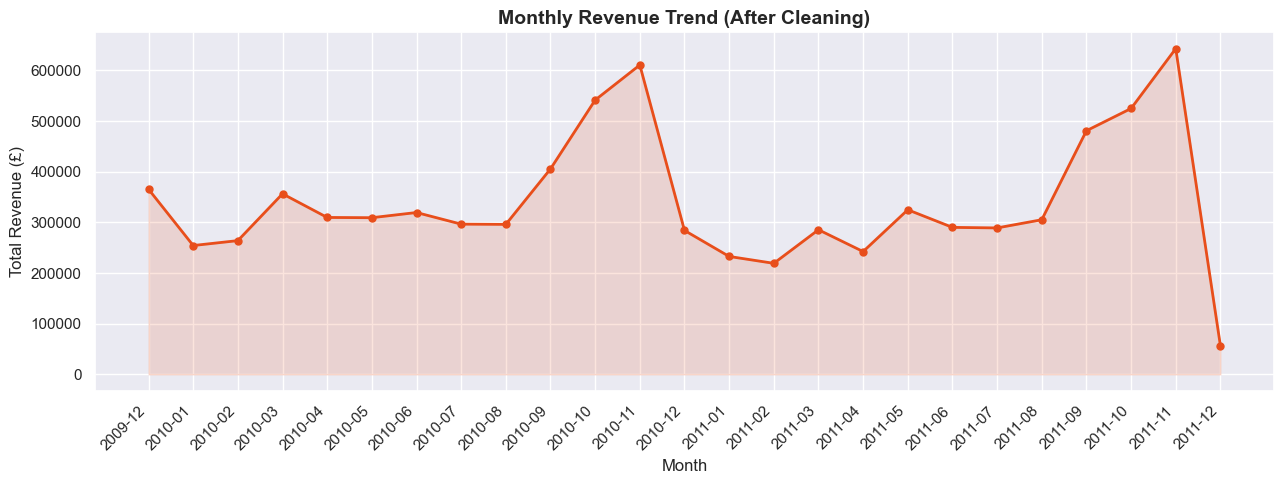

[Chart 7] Scatter – Quantity vs Revenue (coloured by Country)


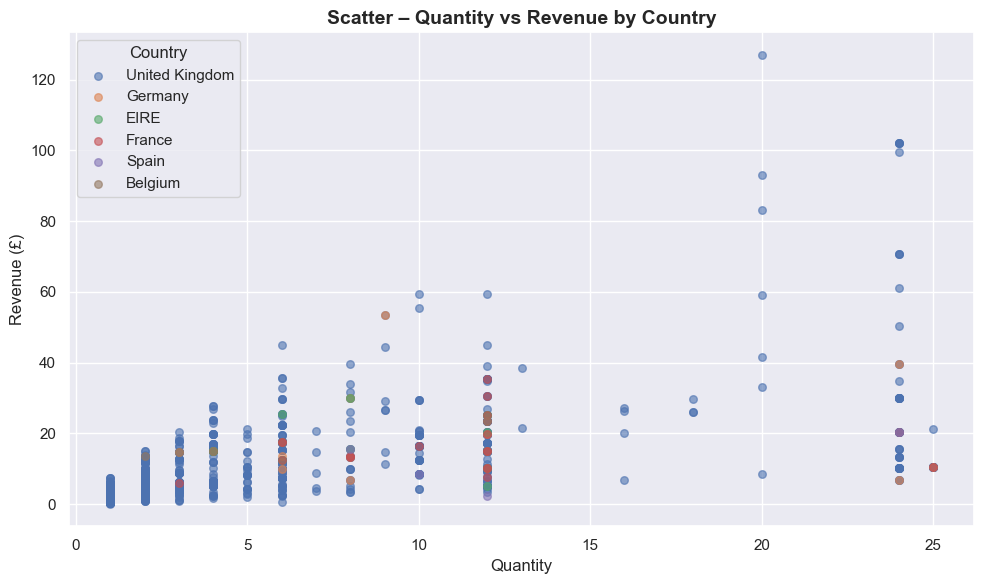

[Chart 8] Scatter – Temperature vs Revenue


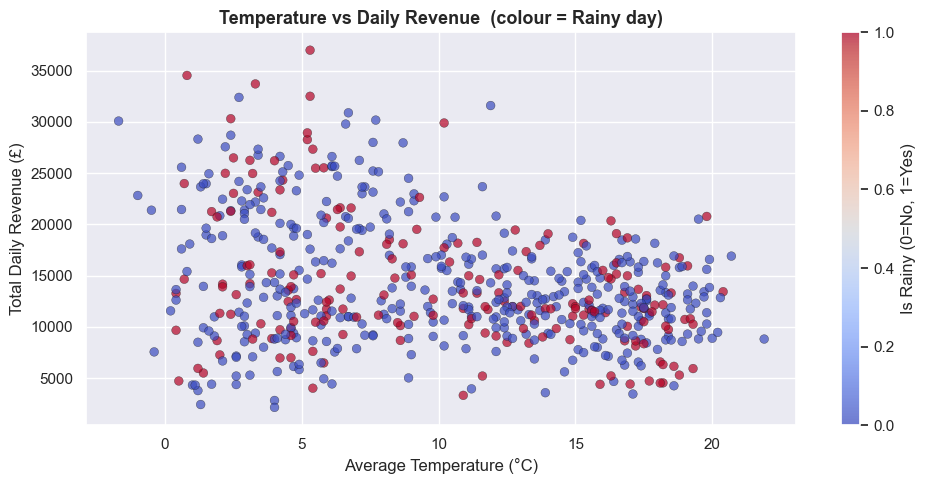

[Chart 9] Top 10 Products by Revenue


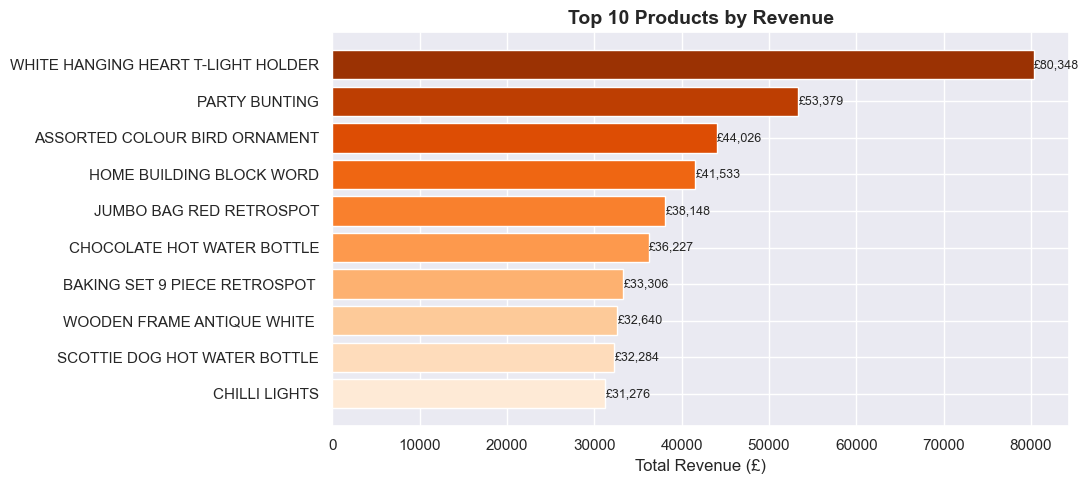

[Chart 10] Revenue by Day of Week


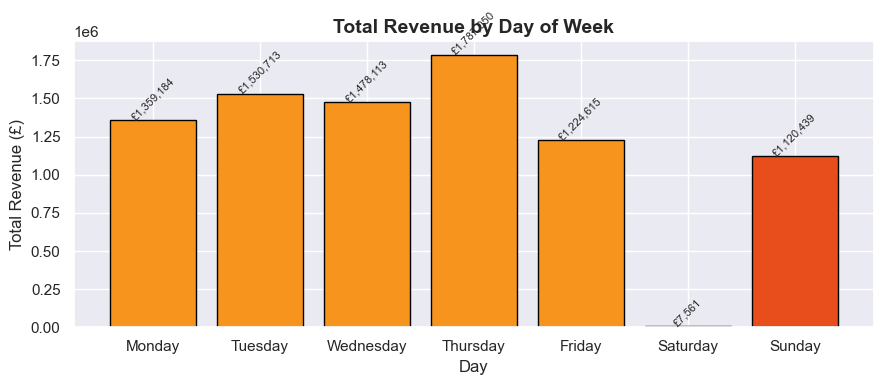

[Chart 11] Revenue by Country (Pie)


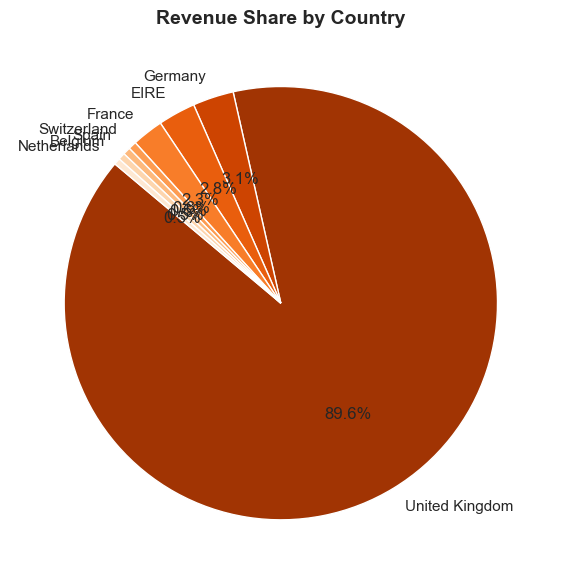

[Chart 12] Customer Age Group Distribution


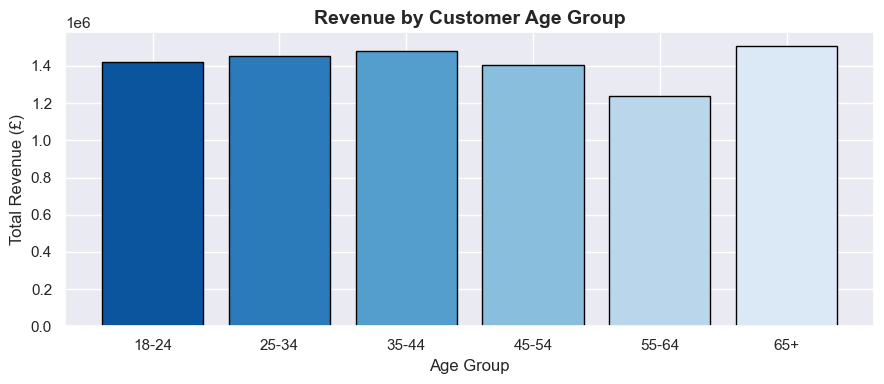

[Chart 13] Our Price vs Competitor Price


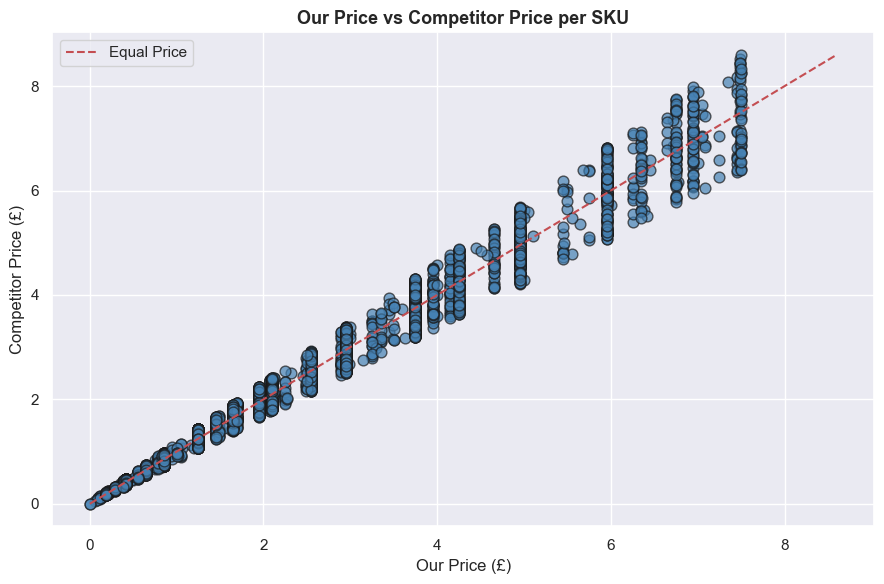

In [10]:


print("\n" + "="*60)
print("  STEP 10 – EDA CHARTS (AFTER CLEANING)")
print("="*60)

# --- Chart 5: Correlation Heatmap ---
print("\n[Chart 5] Correlation Heatmap")
num_cols = ["Quantity", "UnitPrice", "Revenue", "AvgTempC",
            "RainfallMM", "CompetitorPrice", "PriceDiff_Pct", "Age"]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap – Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Chart 6: Monthly Revenue ---
print("[Chart 6] Monthly Revenue Trend")
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
monthly_rev = df.groupby("YearMonth")["Revenue"].sum().reset_index()

plt.figure(figsize=(13, 5))
plt.plot(monthly_rev["YearMonth"], monthly_rev["Revenue"],
         marker="o", color="#E84E1B", linewidth=2, markersize=5)
plt.fill_between(range(len(monthly_rev)), monthly_rev["Revenue"],
                 alpha=0.15, color="#E84E1B")
plt.xticks(range(len(monthly_rev)), monthly_rev["YearMonth"], rotation=45, ha="right")
plt.title("Monthly Revenue Trend (After Cleaning)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue (£)")
plt.tight_layout()
plt.show()

# --- Chart 7: Scatter – Quantity vs Revenue ---
print("[Chart 7] Scatter – Quantity vs Revenue (coloured by Country)")
sample = df.sample(min(1000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
countries_top = df["Country"].value_counts().head(6).index.tolist()
for country in countries_top:
    subset = sample[sample["Country"] == country]
    plt.scatter(subset["Quantity"], subset["Revenue"],
                label=country, alpha=0.6, s=30)
plt.title("Scatter – Quantity vs Revenue by Country", fontsize=14, fontweight="bold")
plt.xlabel("Quantity")
plt.ylabel("Revenue (£)")
plt.legend(title="Country", loc="upper left")
plt.tight_layout()
plt.show()

# --- Chart 8: Scatter – Temperature vs Revenue ---
print("[Chart 8] Scatter – Temperature vs Revenue")
daily_agg = df.groupby(df["InvoiceDate"].dt.date).agg(
    TotalRevenue=("Revenue","sum"),
    AvgTemp=("AvgTempC","mean"),
    IsRainy=("IsRainy","mean"),
).reset_index()

plt.figure(figsize=(10, 5))
scatter = plt.scatter(daily_agg["AvgTemp"], daily_agg["TotalRevenue"],
                      c=daily_agg["IsRainy"], cmap="coolwarm",
                      alpha=0.7, s=40, edgecolors="k", linewidths=0.3)
plt.colorbar(scatter, label="Is Rainy (0=No, 1=Yes)")
plt.title("Temperature vs Daily Revenue  (colour = Rainy day)",
          fontsize=13, fontweight="bold")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Total Daily Revenue (£)")
plt.tight_layout()
plt.show()

# --- Chart 9: Top 10 Products by Revenue ---
print("[Chart 9] Top 10 Products by Revenue")
top10 = df.groupby("Description")["Revenue"].sum().nlargest(10).reset_index()

plt.figure(figsize=(11, 5))
bars = plt.barh(top10["Description"], top10["Revenue"],
                color=sns.color_palette("Oranges_r", 10))
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.gca().invert_yaxis()
for bar, val in zip(bars, top10["Revenue"]):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f"£{val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# --- Chart 10: Revenue by Day of Week ---
print("[Chart 10] Revenue by Day of Week")
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_rev   = df.groupby("DayOfWeek")["Revenue"].sum().reindex(dow_order).reset_index()

plt.figure(figsize=(9, 4))
bars = plt.bar(dow_rev["DayOfWeek"], dow_rev["Revenue"],
               color=["#E84E1B" if d in ["Saturday","Sunday"] else "#F7941D"
                      for d in dow_rev["DayOfWeek"]],
               edgecolor="black")
plt.title("Total Revenue by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Total Revenue (£)")
for bar, val in zip(bars, dow_rev["Revenue"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 200,
             f"£{val:,.0f}", ha="center", fontsize=8, rotation=45)
plt.tight_layout()
plt.show()

# --- Chart 11: Revenue by Country ---
print("[Chart 11] Revenue by Country (Pie)")
country_rev = df.groupby("Country")["Revenue"].sum().nlargest(8).reset_index()

plt.figure(figsize=(9, 6))
plt.pie(country_rev["Revenue"], labels=country_rev["Country"],
        autopct="%1.1f%%", startangle=140,
        colors=sns.color_palette("Oranges_r", len(country_rev)))
plt.title("Revenue Share by Country", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Chart 12: Customer Age Group Distribution ---
print("[Chart 12] Customer Age Group Distribution")
if "AgeGroup" in df.columns:
    age_order = ["18-24","25-34","35-44","45-54","55-64","65+"]
    age_rev   = df.groupby("AgeGroup")["Revenue"].sum().reindex(age_order).reset_index()
    plt.figure(figsize=(9, 4))
    plt.bar(age_rev["AgeGroup"], age_rev["Revenue"],
            color=sns.color_palette("Blues_r", len(age_rev)), edgecolor="black")
    plt.title("Revenue by Customer Age Group", fontsize=14, fontweight="bold")
    plt.xlabel("Age Group")
    plt.ylabel("Total Revenue (£)")
    plt.tight_layout()
    plt.show()

# --- Chart 13: Competitor Price vs Our Price Scatter ---
print("[Chart 13] Our Price vs Competitor Price")
if "CompetitorPrice" in df.columns:
    sku_price_df = df.groupby("StockCode").agg(
        OurPrice=("UnitPrice","median"),
        CompPrice=("CompetitorPrice","median"),
    ).reset_index()

    plt.figure(figsize=(9, 6))
    plt.scatter(sku_price_df["OurPrice"], sku_price_df["CompPrice"],
                alpha=0.7, color="steelblue", s=60, edgecolors="k")
    # 45-degree reference line (equal price)
    max_val = max(sku_price_df[["OurPrice","CompPrice"]].max())
    plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Equal Price")
    plt.title("Our Price vs Competitor Price per SKU", fontsize=13, fontweight="bold")
    plt.xlabel("Our Price (£)")
    plt.ylabel("Competitor Price (£)")
    plt.legend()
    plt.tight_layout()
    plt.show()





## STEP 11 – SAVE CLEANED DATASET

In [11]:


print("\n" + "="*60)
print("  STEP 11 – SAVING CLEANED DATASET")
print("="*60)

output_file = "online_retail_CLEANED.xlsx"
df.to_excel(output_file, index=False)
print(f"\n  ✅  Cleaned dataset saved as:  {output_file}")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"\n  Columns in cleaned file:")
for col in df.columns:
    print(f"    - {col}")

print("\n" + "="*60)
print("  ✅  ALL STEPS COMPLETE!")
print("="*60)
print("""
  Summary of what was done:
  ─────────────────────────────────────────────
  ✔ Loaded dataset
  ✔ Printed full data summary (before cleaning)
  ✔ Handled missing values (drop / fill median)
  ✔ Removed duplicate rows
  ✔ Fixed data types (dates, IDs)
  ✔ Removed invalid rows (neg qty, cancelled)
  ✔ Detected & removed outliers (IQR method)
  ✔ Added: Revenue, Year, Month, DayOfWeek
  ✔ Added: Weather  (AvgTempC, RainfallMM)
  ✔ Added: Competitor Price (CompetitorPrice)
  ✔ Added: Demographics (Age, Region, Gender)
  ✔ Generated 13 charts
  ✔ Saved cleaned file
  ─────────────────────────────────────────────
""")




  STEP 11 – SAVING CLEANED DATASET

  ✅  Cleaned dataset saved as:  online_retail_CLEANED.xlsx
  Rows    : 652,911
  Columns : 24

  Columns in cleaned file:
    - InvoiceNo
    - StockCode
    - Description
    - Quantity
    - InvoiceDate
    - UnitPrice
    - CustomerID
    - Country
    - Revenue
    - Year
    - Month
    - DayOfWeek
    - IsWeekend
    - AvgTempC
    - RainfallMM
    - IsRainy
    - CompetitorPrice
    - PriceDiff_Pct
    - Age
    - AgeGroup
    - Region
    - Gender
    - LoyaltyTier
    - YearMonth

  ✅  ALL STEPS COMPLETE!

  Summary of what was done:
  ─────────────────────────────────────────────
  ✔ Loaded dataset
  ✔ Printed full data summary (before cleaning)
  ✔ Handled missing values (drop / fill median)
  ✔ Removed duplicate rows
  ✔ Fixed data types (dates, IDs)
  ✔ Removed invalid rows (neg qty, cancelled)
  ✔ Detected & removed outliers (IQR method)
  ✔ Added: Revenue, Year, Month, DayOfWeek
  ✔ Added: Weather  (AvgTempC, RainfallMM)
  ✔ Added: Co